# Forestry Canopy Height Analysis Workflow

This notebook demonstrates the complete workflow for analyzing canopy height distributions at forestry inventory locations using LDBV elevation products from Bavaria.

## Data Products Used

| Product | Resolution | Source | Method |
|---------|-----------|--------|--------|
| DGM1 (Ground Model) | 1m | geoservices.bayern.de | WCS 2.0.1 (auth required) |
| DOM20 (Surface Model) | 20cm | bayernwolke.de | Metalink tile download (open data) |
| nDOM (Height Model) | 20cm | derived | DOM - DGM |

## Workflow Overview

1. **Section 0**: Test WCS axis labels and DOM20 tile logic
2. **Section 1**: Setup and configuration
3. **Section 2**: Single point analysis
4. **Section 3**: Transect analysis
5. **Section 4**: Advanced options

---

## Section 0: Service Testing

Run this section to verify:
- LDBV WCS credentials work
- DGM1 WCS axis labels are accepted
- DOM20 tile naming logic produces correct results

In [1]:
# Test LDBV credentials and DGM WCS
import os
import getpass
import requests
from requests.auth import HTTPBasicAuth

# Get credentials
LDBV_USER = os.environ.get("LDBV_USER") or input("LDBV username: ")
LDBV_PASS = os.environ.get("LDBV_PASS") or getpass.getpass("LDBV password: ")

print(f"Credentials set for user: {LDBV_USER}")

Credentials set for user: 25X173451


In [2]:
# Test DGM WCS - determine which axis labels work
print("Testing DGM WCS axis labels...")
print("=" * 60)

dgm_url = "https://geoservices.bayern.de/pro/wcs/dgm/v1/wcs_inspire_dgm1?"
auth = HTTPBasicAuth(LDBV_USER, LDBV_PASS)

# Small test extent (100m x 100m around Freising)
test_minx, test_miny = 692000, 5333000
test_maxx, test_maxy = 692100, 5333100

# Test GetCapabilities first
r_cap = requests.get(dgm_url, params={
    'SERVICE': 'WCS', 'REQUEST': 'GetCapabilities', 'VERSION': '2.0.1'
}, auth=auth, timeout=30)
print(f"GetCapabilities: {r_cap.status_code}")

if r_cap.status_code == 200:
    # Extract axis labels from capabilities (look for AxisLabels)
    import re
    axis_match = re.findall(r'axisLabels="([^"]+)"', r_cap.text)
    if axis_match:
        print(f"\nAxis labels found in capabilities: {axis_match}")

# Test each axis label combination
axis_candidates = [("X", "Y"), ("E", "N"), ("Easting", "Northing"), ("x", "y")]
working_axes = None

for axes in axis_candidates:
    params = [
        ('SERVICE', 'WCS'),
        ('REQUEST', 'GetCoverage'),
        ('VERSION', '2.0.1'),
        ('COVERAGEID', 'EL.ElevationGridCoverage'),
        ('SUBSETTINGCRS', 'EPSG:25832'),
        ('OUTPUTCRS', 'EPSG:25832'),
        ('SUBSET', f'{axes[0]}({test_minx},{test_maxx})'),
        ('SUBSET', f'{axes[1]}({test_miny},{test_maxy})'),
        ('FORMAT', 'image/tiff;application=geotiff'),
    ]
    
    r = requests.get(dgm_url, params=params, auth=auth, timeout=60)
    ctype = r.headers.get('content-type', '')
    
    if r.status_code == 200 and 'tiff' in ctype:
        print(f"\n  Axes ({axes[0]}, {axes[1]}): SUCCESS ({len(r.content):,} bytes)")
        if not working_axes:
            working_axes = axes
    else:
        # Extract error message
        err_msg = ''
        if 'ExceptionText' in r.text:
            err_match = re.search(r'<ows:ExceptionText>(.+?)</ows:ExceptionText>', r.text)
            err_msg = err_match.group(1) if err_match else r.text[:200]
        print(f"\n  Axes ({axes[0]}, {axes[1]}): FAILED - {err_msg}")

print("\n" + "=" * 60)
if working_axes:
    print(f"RESULT: Use axis labels ({working_axes[0]}, {working_axes[1]})")
    print(f"\nUpdate modules/ldbv_download.py if needed.")
else:
    print("RESULT: No axis labels worked!")
    print("Check if the service is temporarily unavailable or credentials expired.")

Testing DGM WCS axis labels...
GetCapabilities: 200

  Axes (X, Y): SUCCESS (40,442 bytes)

  Axes (E, N): FAILED - msWCSValidateAndFindAxes20(): WCS server error. Invalid subset axis 'E'.

  Axes (Easting, Northing): FAILED - msWCSValidateAndFindAxes20(): WCS server error. Invalid subset axis 'Easting'.

  Axes (x, y): SUCCESS (40,442 bytes)

RESULT: Use axis labels (X, Y)

Update modules/ldbv_download.py if needed.


In [3]:
# Test DOM20 tile logic
print("Testing DOM20 tile naming logic...")
print("=" * 60)

import sys
sys.path.insert(0, '..')
from modules.ldbv_download import compute_dom20_tiles, generate_dom20_meta4

# Test with same extent as the example .meta4 (area around 11.97E / 47.98N)
# Those coords in EPSG:25832 are roughly: E=721000-723000, N=5317000-5320000
test_tiles = compute_dom20_tiles(721000, 5317000, 723500, 5320500)

print(f"\nTiles for extent (721000, 5317000) to (723500, 5320500):")
for t in sorted(test_tiles):
    print(f"  {t}")

# Compare with the example .meta4 in project root
print(f"\n\nExpected tiles from example dom20dom.meta4:")
expected = [
    '32721_5318_20_DOM.tif', '32721_5319_20_DOM.tif', '32721_5320_20_DOM.tif',
    '32722_5318_20_DOM.tif', '32722_5319_20_DOM.tif', '32722_5320_20_DOM.tif',
    '32723_5317_20_DOM.tif', '32723_5318_20_DOM.tif', '32723_5319_20_DOM.tif',
    '32723_5320_20_DOM.tif'
]
for t in sorted(expected):
    match = '  ' if t in test_tiles else 'MISSING'
    print(f"  {match} {t}")

# Check overlap
computed_set = set(test_tiles)
expected_set = set(expected)
print(f"\nOverlap: {len(computed_set & expected_set)}/{len(expected_set)} expected tiles found")
extra = computed_set - expected_set
if extra:
    print(f"Extra tiles computed: {sorted(extra)}")

Testing DOM20 tile naming logic...

Tiles for extent (721000, 5317000) to (723500, 5320500):
  32721_5317_20_DOM.tif
  32721_5318_20_DOM.tif
  32721_5319_20_DOM.tif
  32721_5320_20_DOM.tif
  32722_5317_20_DOM.tif
  32722_5318_20_DOM.tif
  32722_5319_20_DOM.tif
  32722_5320_20_DOM.tif
  32723_5317_20_DOM.tif
  32723_5318_20_DOM.tif
  32723_5319_20_DOM.tif
  32723_5320_20_DOM.tif


Expected tiles from example dom20dom.meta4:
     32721_5318_20_DOM.tif
     32721_5319_20_DOM.tif
     32721_5320_20_DOM.tif
     32722_5318_20_DOM.tif
     32722_5319_20_DOM.tif
     32722_5320_20_DOM.tif
     32723_5317_20_DOM.tif
     32723_5318_20_DOM.tif
     32723_5319_20_DOM.tif
     32723_5320_20_DOM.tif

Overlap: 10/10 expected tiles found
Extra tiles computed: ['32721_5317_20_DOM.tif', '32722_5317_20_DOM.tif']


In [4]:
# Test downloading a single DOM20 tile (verify open access)
print("Testing DOM20 tile download (open data, no auth)...")
print("-" * 60)

test_tile = "32722_5318_20_DOM.tif"
test_url = f"https://download1.bayernwolke.de/a/dom20/DOM/{test_tile}"

# Use proxy if behind corporate network
PROXY = os.environ.get("HTTPS_PROXY", None)
proxies = {"https": PROXY, "http": PROXY} if PROXY else None

try:
    r = requests.head(test_url, timeout=30, proxies=proxies)
    print(f"URL: {test_url}")
    print(f"Status: {r.status_code}")
    print(f"Content-Type: {r.headers.get('content-type', 'unknown')}")
    content_length = r.headers.get('content-length', 'unknown')
    if content_length != 'unknown':
        print(f"Size: {int(content_length)/1024/1024:.1f} MB")
    
    if r.status_code == 200:
        print("\n  DOM20 download accessible (open data, no auth needed)")
    else:
        print(f"\n  Unexpected status. Try with proxy?")
except Exception as e:
    print(f"  Connection failed: {e}")
    print("  Check proxy settings (HTTPS_PROXY environment variable)")

Testing DOM20 tile download (open data, no auth)...
------------------------------------------------------------
URL: https://download1.bayernwolke.de/a/dom20/DOM/32722_5318_20_DOM.tif
Status: 200
Content-Type: image/tiff
Size: 44.0 MB

  DOM20 download accessible (open data, no auth needed)


---

## Section 1: Setup and Configuration

In [5]:
# Import modules
import sys
sys.path.insert(0, '..')

from canopy_histogram import canopy_histogram_ldbv
from modules.ldbv_download import get_credentials
import matplotlib.pyplot as plt
import os

%matplotlib inline

print("Modules loaded successfully")

Modules loaded successfully


In [6]:
# Configure credentials
# Option 1: environment variables (set before starting jupyter)
#   export LDBV_USER="your_username"
#   export LDBV_PASS="your_password"

# Option 2: set here (will be prompted if not set)
# os.environ['LDBV_USER'] = 'your_username'
# os.environ['LDBV_PASS'] = 'your_password'

# Option 3: pass directly to canopy_histogram_ldbv(user=..., password=...)

# Optional: proxy for corporate networks
os.environ['HTTPS_PROXY'] = 'http://www-proxy.bayern.de:80'

print("Configuration ready. Credentials will be requested when needed.")

Configuration ready. Credentials will be requested when needed.


---

## Section 2: Single Point Analysis

Analyze canopy height around a single inventory point.

**What happens under the hood:**
1. Coordinate is buffered (circular) to define the analysis area
2. Extent is projected to EPSG:25832 for download
3. DOM20 tiles (1km, 20cm) are downloaded via Metalink (open data)
4. DGM1 (1m) is downloaded via WCS (requires credentials)
5. DGM is resampled to DOM grid (bilinear, 1m -> 0.2m)
6. nDOM = DOM - DGM is computed
7. nDOM is clipped to the circular buffer
8. Height threshold check (25% above 15m)
9. Histogram and plot (if threshold met)

In [7]:
# ══════════════════════════════════════════════════════════════════════════
# DEFINE YOUR ANALYSIS PARAMETERS HERE
# ══════════════════════════════════════════════════════════════════════════

# Inventory point coordinate (WGS84: longitude, latitude)
point_coords = [(11.657712820114519 ,48.40781792348257)]

# Buffer radius in meters
buffer_m = 50

# Height class breaks (meters)
height_classes = [0, 15, 25, 35, 50]

# Threshold: only compute histogram if >= 25% of pixels are above 15m
threshold_height = 15.0  # meters
min_proportion = 0.25    # 25%

# Resolution (0.2m = DOM native, 1.0m = faster)
resolution = 0.2

# ══════════════════════════════════════════════════════════════════════════

print("Analysis parameters:")
print(f"  Point: {point_coords[0]} (WGS84)")
print(f"  Buffer: {buffer_m}m radius -> ~{3.14159 * buffer_m**2 / 10000:.3f} ha")
print(f"  Classes: {height_classes}")
print(f"  Threshold: >= {min_proportion:.0%} above {threshold_height}m")
print(f"  Resolution: {resolution}m")

Analysis parameters:
  Point: (11.657712820114519, 48.40781792348257) (WGS84)
  Buffer: 50m radius -> ~0.785 ha
  Classes: [0, 15, 25, 35, 50]
  Threshold: >= 25% above 15.0m
  Resolution: 0.2m



FORESTRY CANOPY HEIGHT ANALYSIS
[1/11] Validating inputs...
[2/11] Creating analysis geometry (1 point(s), 50m buffer)...
       Analysis area: 0.784 ha (7841.4 m²)
       CRS: EPSG:25832
[3/11] Computing extent...
       EPSG:25832: (np.float64(696627.5794931778), np.float64(5364991.780217183), np.float64(696727.5794931778), np.float64(5365091.780217183))
       EPSG:4326: (11.657038, 48.407369) to (11.658388, 48.408267)
[4/11] Downloading DOM20 tiles + DGM1 WCS...
[1/6] Computing DOM20 tile list...
      2 tile(s): 32696_5364_20_DOM.tif, 32696_5365_20_DOM.tif
[2/6] Downloading DOM20 tiles (open data, no auth)...


DOM20 tiles: 100%|██████████| 2/2 [00:00<00:00, 4029.11it/s]


[3/6] Merging DOM20 tiles into mosaic...


merging: 100%|██████████| 2/2 [00:01<00:00,  1.93it/s]


[4/6] Downloading DGM1 via WCS 2.0.1...
[5/6] Aligning DGM1 to DOM grid (0.2m)...
[6/6] Computing nDOM = DOM - DGM...
      Done. nDOM saved to: C:\Users\lwfeckesim\34_light_availabilityP\temp\ndom_derived.tif
[5/11] Loading derived nDOM...
[6/11] Clipping raster to analysis geometry...
       Clipped size: 501 x 501 pixels
[7/11] Saving clipped raster to C:\Users\lwfeckesim\34_light_availabilityP\temp\point_ndom_clipped.tif...
[8/11] Checking height threshold (15.0m, minimum 25%)...
       Valid cells: 196,038
       Above threshold: 137,006 (69.9%)
       Threshold MET ✓
[9/11] Computing height histogram...
       Classes: 4
[10/11] Generating histogram plot...
       Plot saved: C:\Users\lwfeckesim\34_light_availabilityP\temp\point_histogram.png
[11/11] Generating summary...

CANOPY HEIGHT ANALYSIS SUMMARY
Analysis Area: 0.784 ha (7841.4 m²)
Resolution: 0.2 m
CRS: EPSG:25832

HEIGHT THRESHOLD ANALYSIS
------------------------------------------------------------
Threshold: 15.0 m
Tot

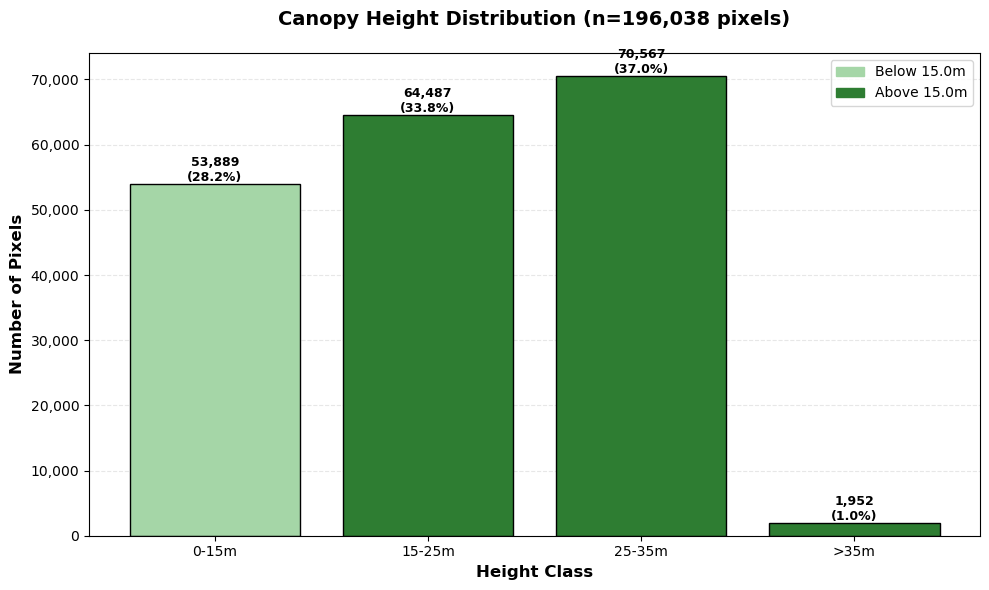

In [8]:
# Run full analysis
results_point = canopy_histogram_ldbv(
    coords=point_coords,
    radius_m=buffer_m,
    classes=height_classes,
    threshold_height_m=threshold_height,
    min_prop_above_threshold=min_proportion,
    target_resolution_m=resolution,
    output_plot_path= r"C:\Users\lwfeckesim\34_light_availabilityP\temp\point_histogram.png",
    output_clipped_raster_path= r"C:\Users\lwfeckesim\34_light_availabilityP\temp\point_ndom_clipped.tif",
    temp_dir= r"C:\Users\lwfeckesim\34_light_availabilityP\temp",
    verbose=True
)

In [9]:
# Display text summary
print(results_point['analysis']['summary_text'])

CANOPY HEIGHT ANALYSIS SUMMARY
Analysis Area: 0.784 ha (7841.4 m²)
Resolution: 0.2 m
CRS: EPSG:25832

HEIGHT THRESHOLD ANALYSIS
------------------------------------------------------------
Threshold: 15.0 m
Total valid pixels: 196,038
Pixels above threshold: 137,006 (69.9%)
Maximum height: 42.89 m
Mean height (all): 19.19 m
Mean height (above threshold): 25.40 m

HEIGHT DISTRIBUTION
------------------------------------------------------------
         0-15m:   53,889 pixels ( 27.5%)
        15-25m:   64,487 pixels ( 32.9%)
        25-35m:   70,567 pixels ( 36.0%)
          >35m:    1,952 pixels (  1.0%)


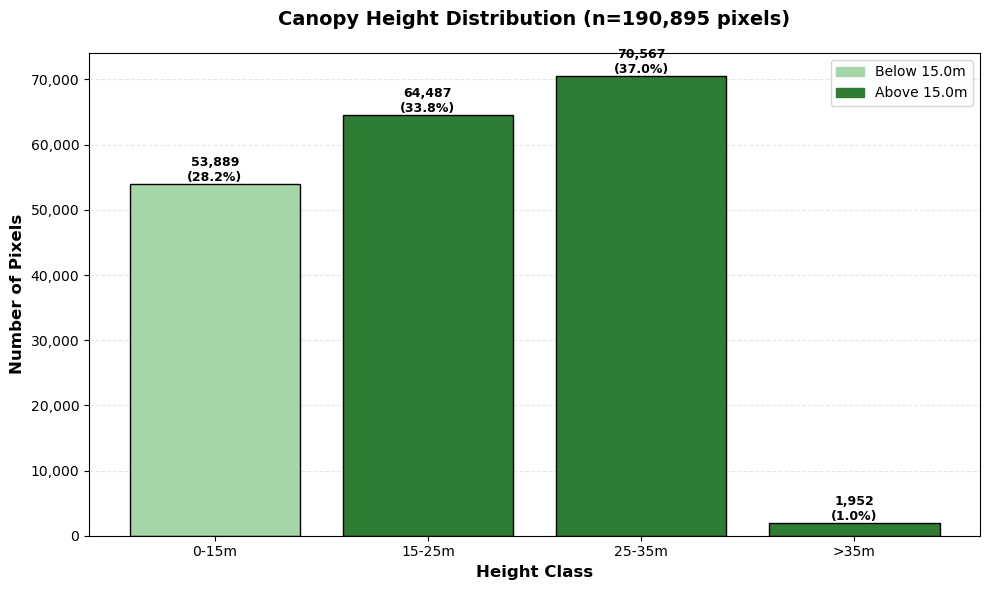

In [10]:
# Show histogram plot (if threshold was met)
if results_point['analysis']['threshold_met']:
    from modules.plotting import plot_height_histogram
    fig = plot_height_histogram(
        results_point['analysis']['histogram']['class_labels'],
        results_point['analysis']['histogram']['class_counts'],
        threshold_height
    )
    plt.show()
else:
    stats = results_point['analysis']['threshold_stats']
    print(f"Histogram not generated.")
    print(f"Only {stats['proportion_above_threshold']:.1%} of pixels above {threshold_height}m")
    print(f"(Required: >= {min_proportion:.0%})")

In [11]:
# Access detailed geometry and download info
print("Geometry:")
print(f"  Area: {results_point['geometry']['area_ha']:.3f} ha")
print(f"  CRS: {results_point['geometry']['crs_metric']}")
print(f"  Extent (EPSG:25832): {results_point['geometry']['extent_25832']}")
print(f"  Extent (WGS84): {results_point['geometry']['extent_4326']}")

print(f"\nRaster:")
print(f"  Resolution: {results_point['raster']['resolution_m']}m")
stats = results_point['raster']['stats']
print(f"  Valid cells: {stats['valid_cells']:,}")
if stats['min'] is not None:
    print(f"  Height range: {stats['min']:.2f} - {stats['max']:.2f}m")
    print(f"  Mean height: {stats['mean']:.2f}m")

print(f"\nDownload:")
print(f"  Mode: {results_point['download_info']['mode']}")
for key, path in results_point['download_info']['files'].items():
    print(f"  {key}: {path}")

Geometry:
  Area: 0.784 ha
  CRS: EPSG:25832
  Extent (EPSG:25832): (np.float64(696627.5794931778), np.float64(5364991.780217183), np.float64(696727.5794931778), np.float64(5365091.780217183))
  Extent (WGS84): {'xmin': np.float64(11.65703792380968), 'ymin': np.float64(48.407368580645574), 'xmax': np.float64(11.658387715843446), 'ymax': np.float64(48.40826726627576), 'crs': 'EPSG:4326'}

Raster:
  Resolution: 0.2m
  Valid cells: 196,038
  Height range: -1.81 - 42.89m
  Mean height: 19.19m

Download:
  Mode: wcs_download
  dom: C:\Users\lwfeckesim\34_light_availabilityP\temp\dom20_mosaic.tif
  dgm: C:\Users\lwfeckesim\34_light_availabilityP\temp\dgm1_downloaded.tif
  ndom: C:\Users\lwfeckesim\34_light_availabilityP\temp\ndom_derived.tif


---

## Section 3: Transect Analysis

Analyze canopy height along a transect defined by start and end points.

Two modes available:
- **`buffer_line`**: Creates a corridor (buffered line) between the two points
- **`midpoint_circle`**: Creates a circular buffer at the midpoint between the two points

In [12]:
# ══════════════════════════════════════════════════════════════════════════
# DEFINE TRANSECT PARAMETERS
# ══════════════════════════════════════════════════════════════════════════

# Start and end points (WGS84: longitude, latitude)
transect_coords = [
    (11.656282496251734, 48.407008760437435),  # Start
    (11.652597426484576, 48.40698477732181)   # End
]

# Buffer width (meters from centerline)
transect_buffer_m = 50

# Mode: "buffer_line" or "midpoint_circle"
transect_mode = "buffer_line"

# ══════════════════════════════════════════════════════════════════════════

print(f"Transect:")
print(f"  Start: {transect_coords[0]}")
print(f"  End:   {transect_coords[1]}")
print(f"  Buffer: {transect_buffer_m}m")
print(f"  Mode: {transect_mode}")

Transect:
  Start: (11.656282496251734, 48.407008760437435)
  End:   (11.652597426484576, 48.40698477732181)
  Buffer: 50m
  Mode: buffer_line



FORESTRY CANOPY HEIGHT ANALYSIS
[1/11] Validating inputs...
[2/11] Creating analysis geometry (transect (buffer_line), 50m buffer)...
       Analysis area: 3.513 ha (35127.7 m²)
       CRS: EPSG:32632
[3/11] Computing extent...
       EPSG:25832: (np.float64(696252.3169024842), np.float64(5364886.105726103), np.float64(696624.8118069278), np.float64(5364998.127394343))
       EPSG:4326: (11.651922, 48.406535) to (11.656958, 48.407458)
[4/11] Downloading DOM20 tiles + DGM1 WCS...
[1/6] Computing DOM20 tile list...
      1 tile(s): 32696_5364_20_DOM.tif
[2/6] Downloading DOM20 tiles (open data, no auth)...


DOM20 tiles: 100%|██████████| 1/1 [00:00<00:00, 2137.77it/s]


[3/6] Merging DOM20 tiles into mosaic...


merging: 100%|██████████| 1/1 [00:01<00:00,  1.52s/it]


[4/6] Downloading DGM1 via WCS 2.0.1...
[5/6] Aligning DGM1 to DOM grid (0.2m)...
[6/6] Computing nDOM = DOM - DGM...
      Done. nDOM saved to: C:\Users\lwfeckesim\34_light_availabilityP\temp\ndom_derived.tif
[5/11] Loading derived nDOM...
[6/11] Clipping raster to analysis geometry...
       Clipped size: 561 x 1864 pixels
[7/11] Skipping clipped raster save (no output path)
[8/11] Checking height threshold (15.0m, minimum 25%)...
       Valid cells: 878,185
       Above threshold: 806,890 (91.9%)
       Threshold MET ✓
[9/11] Computing height histogram...
       Classes: 4
[10/11] Generating histogram plot...
       Plot saved: C:\Users\lwfeckesim\34_light_availabilityP\temp\transect_histogram.png
[11/11] Generating summary...

CANOPY HEIGHT ANALYSIS SUMMARY
Analysis Area: 3.513 ha (35127.7 m²)
Resolution: 0.2 m
CRS: EPSG:32632

HEIGHT THRESHOLD ANALYSIS
------------------------------------------------------------
Threshold: 15.0 m
Total valid pixels: 878,185
Pixels above threshold:

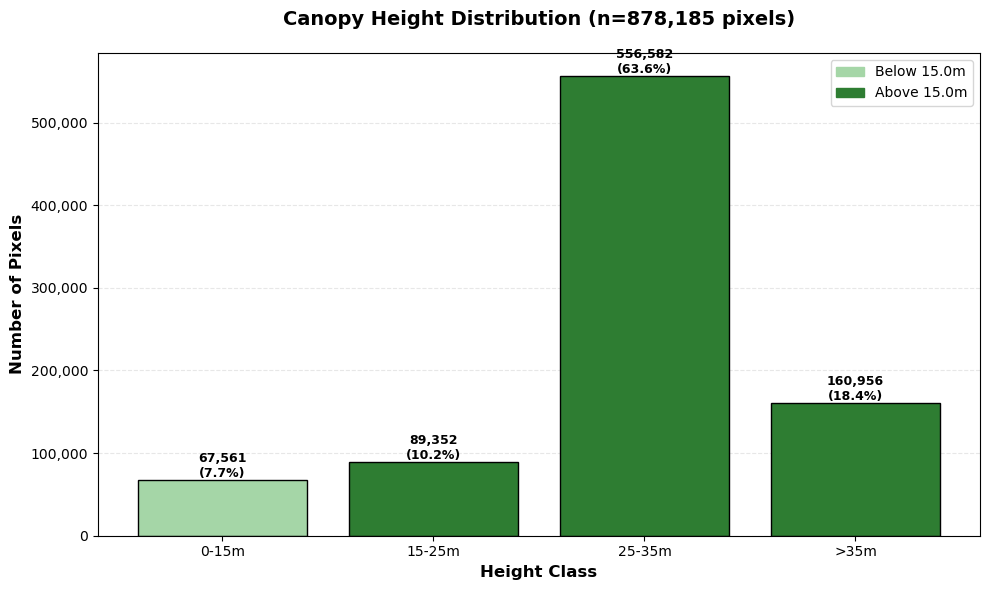

In [13]:
# Run transect analysis
results_transect = canopy_histogram_ldbv(
    coords=transect_coords,
    radius_m=transect_buffer_m,
    classes=height_classes,
    transect_mode=transect_mode,
    target_resolution_m=resolution,
    output_plot_path=r"C:\Users\lwfeckesim\34_light_availabilityP\temp\transect_histogram.png",
    temp_dir=r"C:\Users\lwfeckesim\34_light_availabilityP\temp",
    verbose=True
)

In [14]:
# Display summary
print(results_transect['analysis']['summary_text'])

CANOPY HEIGHT ANALYSIS SUMMARY
Analysis Area: 3.513 ha (35127.7 m²)
Resolution: 0.2 m
CRS: EPSG:32632

HEIGHT THRESHOLD ANALYSIS
------------------------------------------------------------
Threshold: 15.0 m
Total valid pixels: 878,185
Pixels above threshold: 806,890 (91.9%)
Maximum height: 44.69 m
Mean height (all): 29.33 m
Mean height (above threshold): 31.42 m

HEIGHT DISTRIBUTION
------------------------------------------------------------
         0-15m:   67,561 pixels (  7.7%)
        15-25m:   89,352 pixels ( 10.2%)
        25-35m:  556,582 pixels ( 63.4%)
          >35m:  160,956 pixels ( 18.3%)


merging: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it]


Transect Mode Comparison

buffer_line:
  Area: 3.513 ha
  Pixels: 878,185
  Above threshold: 91.9%

midpoint_circle:
  Area: 0.784 ha
  Pixels: 196,032
  Above threshold: 96.9%


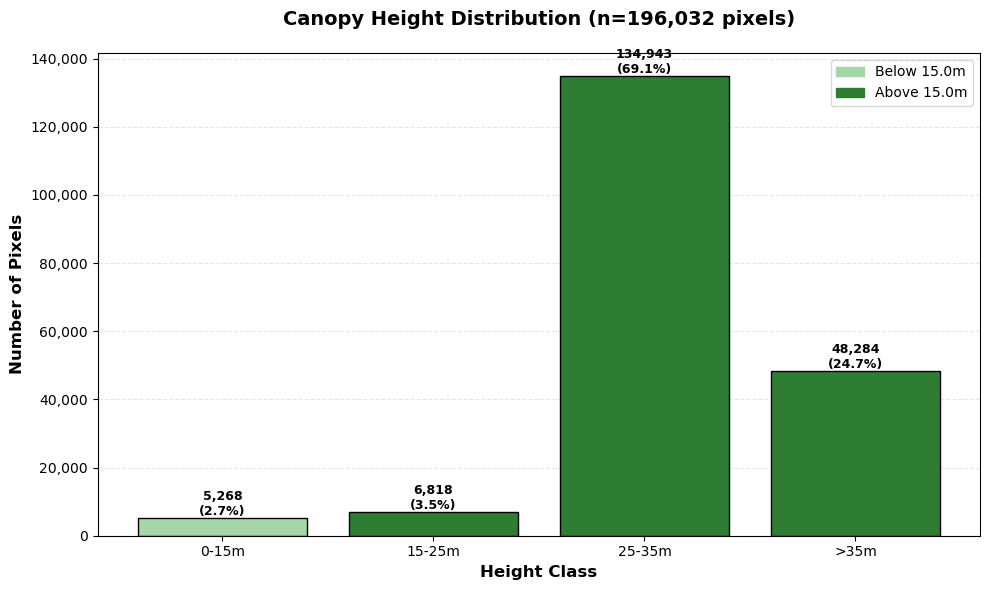

In [15]:
# Compare buffer_line vs midpoint_circle
results_midpoint = canopy_histogram_ldbv(
    coords=transect_coords,
    radius_m=transect_buffer_m,
    classes=height_classes,
    transect_mode="midpoint_circle",
    target_resolution_m=resolution,
    temp_dir="../temp",
    verbose=False
)

print("Transect Mode Comparison")
print("=" * 60)
print(f"\nbuffer_line:")
print(f"  Area: {results_transect['geometry']['area_ha']:.3f} ha")
print(f"  Pixels: {results_transect['raster']['stats']['valid_cells']:,}")
print(f"  Above threshold: {results_transect['analysis']['threshold_stats']['proportion_above_threshold']:.1%}")
print(f"\nmidpoint_circle:")
print(f"  Area: {results_midpoint['geometry']['area_ha']:.3f} ha")
print(f"  Pixels: {results_midpoint['raster']['stats']['valid_cells']:,}")
print(f"  Above threshold: {results_midpoint['analysis']['threshold_stats']['proportion_above_threshold']:.1%}")

---

## Section 4: Advanced Options

In [ ]:
# Use pre-downloaded rasters (skip WCS download)
# Useful if you already have DOM/DGM files from GeoDatenOnline

# Option A: Use a pre-normalized height raster
# results = canopy_histogram_ldbv(
#     coords=[(11.5234, 48.1372)],
#     radius_m=50,
#     classes=[0, 15, 25, 35, 50],
#     analysis_raster="path/to/your_ndom.tif"
# )

# Option B: Use separate DOM and DGM files
# results = canopy_histogram_ldbv(
#     coords=[(11.5234, 48.1372)],
#     radius_m=50,
#     classes=[0, 15, 25, 35, 50],
#     dom_raster="path/to/DOM.tif",
#     dgm_raster="path/to/DGM.tif"
# )

print("Uncomment one of the options above to use local raster files.")

In [ ]:
# Export results to CSV
import pandas as pd

if results_point['analysis']['threshold_met']:
    hist = results_point['analysis']['histogram']
    df = pd.DataFrame({
        'height_class': hist['class_labels'],
        'pixel_count': hist['class_counts'],
        'proportion': hist['class_proportions']
    })
    df.to_csv('../temp/histogram_data.csv', index=False)
    print("Histogram data:")
    print(df.to_string(index=False))
else:
    print("No histogram to export (threshold not met)")

In [ ]:
# Generate tiles manually (preview without download)
from modules.ldbv_download import compute_dom20_tiles, generate_dom20_meta4
from modules.geometry import create_analysis_geometry, compute_extent_25832
import pyproj

# Show which tiles would be needed for a given location
preview_coords = [(11.5234, 48.1372)]
preview_buffer = 50

geom = create_analysis_geometry(
    coords=preview_coords,
    radius_m=preview_buffer,
    transect_mode="buffer_line",
    input_crs=pyproj.CRS("EPSG:4326")
)
extent = compute_extent_25832(geom)

tiles = compute_dom20_tiles(*extent)
print(f"Location: {preview_coords[0]}")
print(f"Buffer: {preview_buffer}m")
print(f"Extent (EPSG:25832): {extent}")
print(f"\nDOM20 tiles needed ({len(tiles)}):")
for t in sorted(tiles):
    print(f"  {t}")

---

## Troubleshooting

### DGM WCS fails
- Run Section 0 to identify the correct axis labels
- Update `axis_candidates` in `modules/ldbv_download.py` if needed
- Check credentials: `LDBV_USER` / `LDBV_PASS`

### DOM20 download fails
- DOM20 is open data (no auth), but may need a proxy
- Set `HTTPS_PROXY` environment variable
- Or set `os.environ['HTTPS_PROXY'] = 'http://your-proxy:port'`

### Memory issues
- Reduce buffer radius
- Use `target_resolution_m=1.0` for faster processing
- A 50m buffer at 0.2m = ~196k pixels; at 1.0m = ~8k pixels

### Threshold not met
- Location may have low canopy cover
- Inspect `results['analysis']['threshold_stats']` for actual proportions
- Adjust `threshold_height_m` or `min_prop_above_threshold`